# 1. Imports et configuration

In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. Lecture du fichier CSV

In [2]:
## Lecture du fichier CSV
data = pd.read_csv('car_prices.csv', parse_dates=['saledate'], infer_datetime_format=True)

## Affichage des premières lignes
display(data.head())

## Informations générales sur le DataFrame
data.info()

C:\Users\Bury\AppData\Local\Temp\ipykernel_23756\396265371.py:2: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv('car_prices.csv', parse_dates=['saledate'], infer_datetime_format=True)
C:\Users\Bury\AppData\Local\Temp\ipykernel_23756\396265371.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('car_prices.csv', parse_dates=['saledate'], infer_datetime_format=True)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


# 3. Nettoyage du fichier

In [3]:
## Harmonisation des valeurs dans la colonne 'body'
data['body'] = data['body'].str.lower().str.strip()

## Identification des valeurs manquantes
valeurs_manquantes = data.isna().sum()
print("Valeurs manquantes (avant nettoyage) :")
print(valeurs_manquantes)

## Remplissage des valeurs manquantes pour 'make', 'model', et 'body'
colonnes_a_traiter = ['make', 'model', 'body']
data[colonnes_a_traiter] = data[colonnes_a_traiter].fillna('inconnu')

## Remplissage des valeurs manquantes pour les colonnes numériques
for col in ['sellingprice', 'odometer']:
    data[col] = data[col].fillna(data[col].median())

## Suppression des lignes avec des valeurs manquantes dans 'mmr'
data = data.dropna(subset=['mmr'])

## Vérification des valeurs manquantes après nettoyage
valeurs_manquantes_apres = data.isna().sum()
print("\nValeurs manquantes (après nettoyage) :")
print(valeurs_manquantes_apres)

Valeurs manquantes (avant nettoyage) :
year                0
make            10301
model           10399
trim            10651
body            13195
transmission    65352
vin                 4
state               0
condition       11820
odometer           94
color             749
interior          749
seller              0
mmr                38
sellingprice       12
saledate           12
dtype: int64

Valeurs manquantes (après nettoyage) :
year                0
make                0
model               0
trim            10651
body                0
transmission    65351
vin                 0
state               0
condition       11794
odometer            0
color             749
interior          749
seller              0
mmr                 0
sellingprice        0
saledate            0
dtype: int64


# 4. Analyse des carrosseries (body)

                  Body Type  Percentage
0                     sedan        43.0
1                       suv        26.0
2                 hatchback         5.0
3                   minivan         5.0
4                     coupe         3.0
5                  crew cab         3.0
6                     wagon         3.0
7                   inconnu         2.0
8               convertible         2.0
9                 supercrew         2.0
10                  g sedan         1.0
11                 supercab         1.0
12              regular cab         1.0
13                      van         1.0
14             extended cab         1.0
15                 quad cab         1.0
16             e-series van         0.0
17               double cab         0.0
18                  g coupe         0.0
19              crewmax cab         0.0
20                 king cab         0.0
21            g convertible         0.0
22               access cab         0.0
23            genesis coupe         0.0


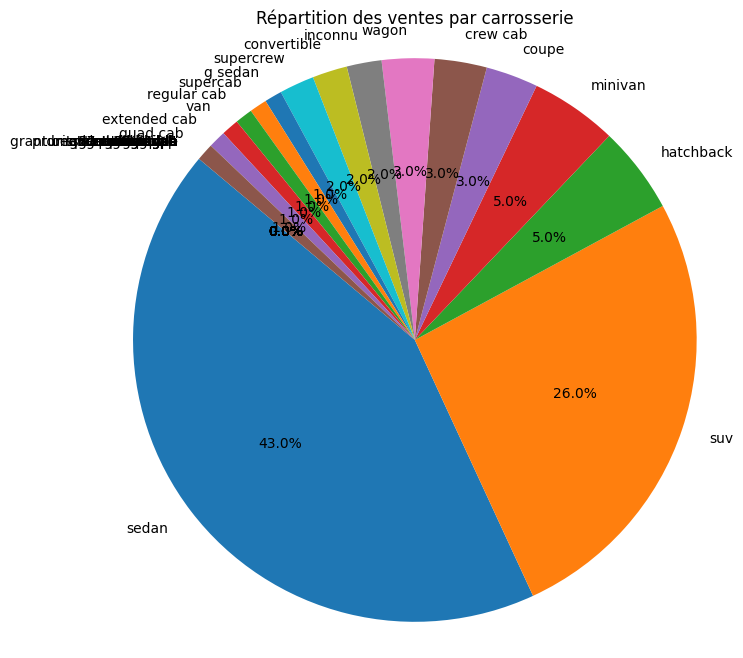

In [4]:
## Analyse des carrosseries ('body')
distrib_body = data['body'].value_counts(normalize=True).round(2) * 100
distrib_body_df = distrib_body.reset_index()
distrib_body_df.columns = ['Body Type', 'Percentage']
print(distrib_body_df)

## Visualisation de la répartition des carrosseries
plt.figure(figsize=(8, 8))
plt.pie(distrib_body_df['Percentage'], labels=distrib_body_df['Body Type'], autopct='%1.1f%%', startangle=140)
plt.title("Répartition des ventes par carrosserie")
plt.axis('equal')
plt.show()

# 5. Analyse des ventes par constructeur (make)

make
Ford             17.884596
Chevrolet         9.479388
Nissan            8.325952
Toyota            6.421140
BMW               5.840835
Mercedes-Benz     4.865676
Dodge             4.524559
Infiniti          4.108450
Honda             3.913291
Lexus             3.163485
Name: sellingprice, dtype: float64


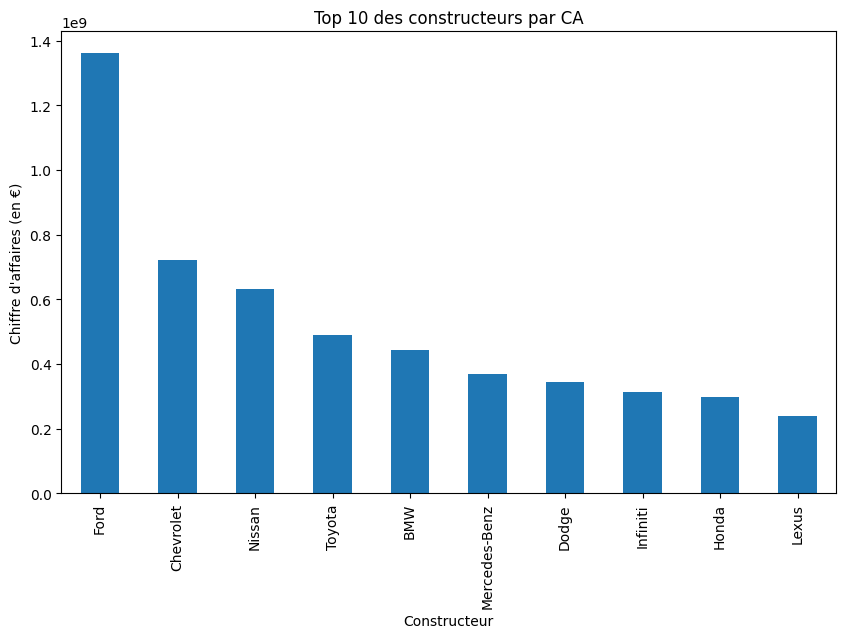

In [5]:
ca_par_make = data.groupby('make')['sellingprice'].sum().sort_values(ascending=False)
distrib_make_df = ca_par_make / ca_par_make.sum() * 100
print(distrib_make_df.head(10))

## Visualisation de la répartition du CA par constructeur
plt.figure(figsize=(10, 6))
ca_par_make.head(10).plot(kind='bar', title="Top 10 des constructeurs par CA")
plt.xlabel("Constructeur")
plt.ylabel("Chiffre d'affaires (en €)")
plt.show()

# 6. Analyse de l'écart entre les prix de vente estimés et réels

Statistiques des écarts de prix :
count    558799.00
mean       -158.02
std        1758.94
min      -87750.00
25%        -800.00
50%         -50.00
75%         650.00
max      207200.00
Name: price_gap, dtype: float64


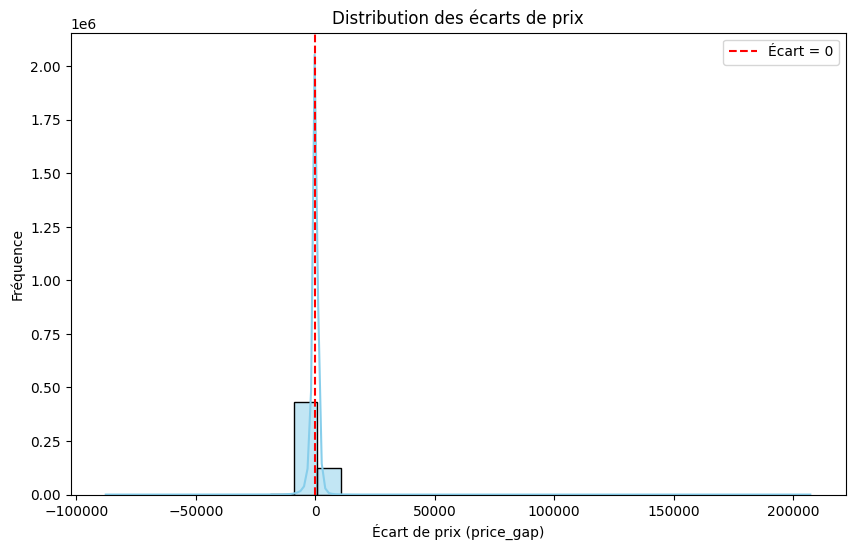

In [6]:
data['price_gap'] = data['sellingprice'] - data['mmr']
price_gap_stats = data['price_gap'].describe().round(2)
print("Statistiques des écarts de prix :")
print(price_gap_stats)

## Visualisation des écarts de prix
plt.figure(figsize=(10, 6))
sns.histplot(data['price_gap'], bins=30, kde=True, color='skyblue')
plt.title("Distribution des écarts de prix")
plt.xlabel("Écart de prix (price_gap)")
plt.ylabel("Fréquence")
plt.axvline(0, color='red', linestyle='--', label='Écart = 0')
plt.legend()
plt.show()

# 7. Analyse de la corrélation entre le prix de vente (sellingprice) et le kilométrage (odometer)

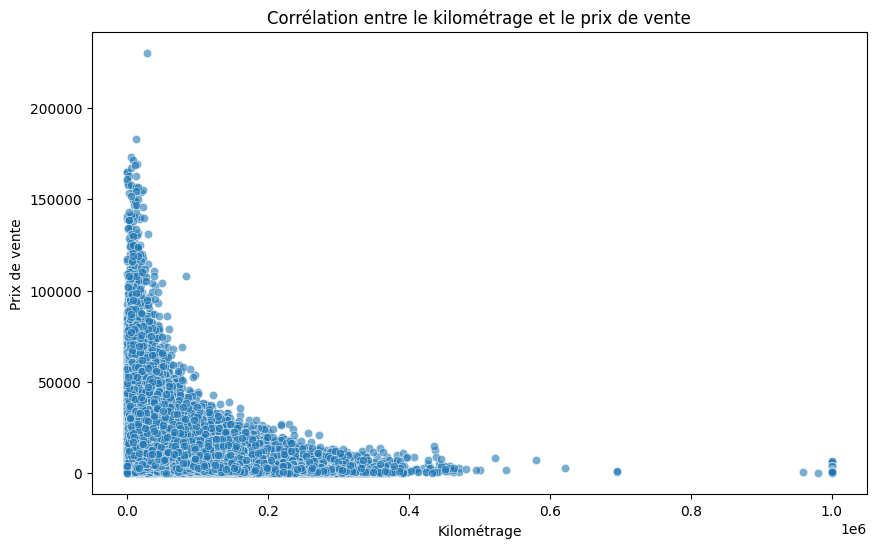

In [7]:
## Corrélation entre 'odometer' et 'sellingprice'
plt.figure(figsize=(10, 6))
sns.scatterplot(x='odometer', y='sellingprice', data=data, alpha=0.6)
plt.title("Corrélation entre le kilométrage et le prix de vente")
plt.xlabel("Kilométrage")
plt.ylabel("Prix de vente")
plt.show()

# 8. Analyse des modèles les plus rentables

Les modèles les plus rentables sont :
model
F-150             272669759.0
Altima            220986008.0
Escape            165884802.0
Fusion            159912520.0
G Sedan           147918806.0
Explorer          140340694.0
Camry             140246808.0
3 Series          137906230.0
Edge              110867719.0
Silverado 1500    107318746.0
Name: sellingprice, dtype: float64


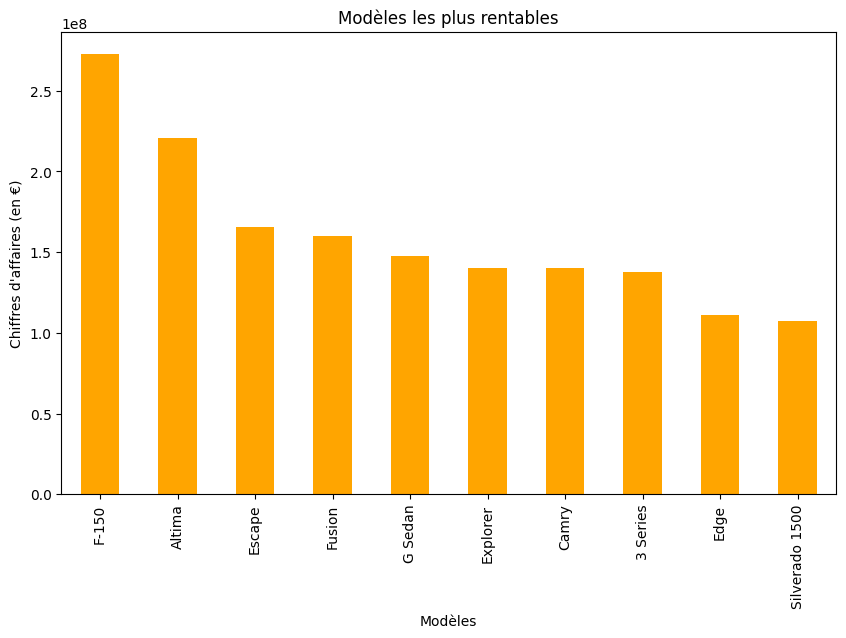

In [8]:
## Analyse du modèle le plus rentable
ca_par_model = data.groupby('model')['sellingprice'].sum().sort_values(ascending=False).round(2).head(10)
print("Les modèles les plus rentables sont :")
print(ca_par_model)

plt.figure(figsize=(10,6))
ca_par_model.plot(kind='bar', title='Modèles les plus rentables', color='orange')
plt.xlabel("Modèles")
plt.ylabel("Chiffres d'affaires (en €)")
plt.show()